### Checking if $\mathcal{L}\hat{Q}=0$ in the subcritical case

In [16]:
include("sub_elliptical.jl")
using LinearAlgebra
using LaTeXStrings

In [ ]:
l_inner_x = 3pi/2
l_inner_y = 3pi/2
v=0

A = sub_ellipse(v,l_inner_x,l_inner_y,5*l_inner_x,5*l_inner_y,150,true)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



([0.0 0.0 … 0.0 0.0; 0.0 -1.543246160530529e-20 … 6.902887850979504e-20 0.0; … ; 0.0 9.208338387565403e-21 … -5.1516387960243165e-20 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 6.200934229541324e-21 … 5.173417082119106e-20 0.0; … ; 0.0 4.366336294894633e-21 … -4.5545975599747335e-20 0.0; 0.0 0.0 … 0.0 0.0], [0.141391757264038 0.1437796330017157 … -0.0033283088213189784 -0.003429420812915839; 0.14526097220404782 0.14586048373352883 … -0.0036738102920168456 -0.0038171049832593958; … ; 0.14486874679555 0.14564646853837046 … -0.0036961707346621865 -0.003812504709653151; 0.1407796321048674 0.14334478419344954 … -0.003313086373772562 -0.0033860212912587596], [0.03606340743088041 0.020025456708140606 … -0.00099588954460598 -0.0014794659007243683; 0.020406032235380907 0.0040756630365944 … -0.000688941123785546 -0.0011890939783527166; … ; 0.022258344214883614 0.005947605382307665 … -0.000996742490450367 -0.0015058087559518575; 0.037844886025434565 0.02184742157944858 … -0.00129731556099302

In [3]:
x_array = -5*l_inner_x/2:A[5]:5*l_inner_x/2
y_array = -5*l_inner_y/2:A[10]:5*l_inner_y/2

lx = A[6]
rx = A[7]
ly = A[8]
ry = A[9]

92

In [4]:
# data
thrust = sup_x_thrust_Q(A[8], A[9], A[6], A[7], A[5], A[10], A[1], A[2],A[3],A[4])
pwr = sup_q_pwr(A[8], A[9], A[6], A[7],A[5],A[10],A[1],A[2],A[3],A[4],v)

0.5705547090931818

#### Making the operator $\mathcal{L}$.

In [10]:
function lq(A,v)
    a = l_inner_x/2
    b = l_inner_y/2
    n = length(A[1][1,:])
    lq_real = zeros(n,n)
    lq_imag = zeros(n,n)
    lq_rcentre = zeros(n,n)
    dx = A[5]
    dy = A[10]
    lhs_x = -5*l_inner_x/2 
    lhs_y = -5*l_inner_y/2
    for xi in 1:n
        for yi in 1:n
            # check if it is in the ellipse
            x = lhs_x + (xi-1)*dx # minus one because we start xi at 1
            y = lhs_y + (yi-1)*dy
            if (x/a)^2 + (y/b)^2 > 1 -2dx
                # do nothing
            elseif (x/a)^2 + (y/b)^2 > 1- 2*dy && (x/a)^2 + (y/b)^2 <= 1 && y<0 && x<0
                re = ((1-v^2)*second_forw_x(A[1],dx,yi,xi)
                        + 2*v*first_forw_x(A[2],dx,yi,xi) 
                        + second_forw_y(A[1],dy,yi,xi)
                        + A[1][yi,xi])
                im = ((1-v^2)*second_forw_x(A[2],dx,yi,xi)
                        - 2*v*first_forw_x(A[1],dx,yi,xi)
                        + second_forw_y(A[2],dy,yi,xi)
                        + A[2][yi,xi])
                lq_real[yi,xi] = abs(re)
                lq_imag[yi,xi] = abs(im)
            elseif (x/a)^2 + (y/b)^2 > 1- 2*dy && (x/a)^2 + (y/b)^2 <= 1 && y>=0 && x>=0
                re = ((1-v^2)*second_back_x(A[1],dx,yi,xi)
                        + 2*v*first_back_x(A[2],dx,yi,xi) 
                        + second_back_y(A[1],dy,yi,xi)
                        + A[1][yi,xi])
                im = ((1-v^2)*second_back_x(A[2],dx,yi,xi)
                        - 2*v*first_back_x(A[1],dx,yi,xi)
                        + second_back_y(A[2],dy,yi,xi)
                        + A[2][yi,xi])
                lq_real[yi,xi] = abs(re)
                lq_imag[yi,xi] = abs(im)
            elseif (x/a)^2 + (y/b)^2 > 1- 2*dy && (x/a)^2 + (y/b)^2 <= 1 && y<0 && x>=0
                re = ((1-v^2)*second_back_x(A[1],dx,yi,xi)
                        + 2*v*first_back_x(A[2],dx,yi,xi) 
                        + second_forw_y(A[1],dy,yi,xi)
                        + A[1][yi,xi])
                im = ((1-v^2)*second_back_x(A[2],dx,yi,xi)
                        - 2*v*first_back_x(A[1],dx,yi,xi)
                        + second_forw_y(A[2],dy,yi,xi)
                        + A[2][yi,xi])
                lq_real[yi,xi] = abs(re)
                lq_imag[yi,xi] = abs(im)
            elseif (x/a)^2 + (y/b)^2 > 1- 2*dy && (x/a)^2 + (y/b)^2 <= 1 && y>=0 && x<0
                re = ((1-v^2)*second_forw_x(A[1],dx,yi,xi)
                        + 2*v*first_forw_x(A[2],dx,yi,xi) 
                        + second_back_y(A[1],dy,yi,xi)
                        + A[1][yi,xi])
                im = ((1-v^2)*second_forw_x(A[2],dx,yi,xi)
                        - 2*v*first_forw_x(A[1],dx,yi,xi)
                        + second_back_y(A[2],dy,yi,xi)
                        + A[2][yi,xi])
                lq_real[yi,xi] = abs(re)
                lq_imag[yi,xi] = abs(im)
            else
                re = ((1-v^2)*second_centred_x(A[1],dx,yi,xi)
                        + 2*v*first_centred_x(A[2],dx,yi,xi) 
                        + second_centred_y(A[1],dy,yi,xi)
                        + A[1][yi,xi])
                im = ((1-v^2)*second_centred_x(A[2],dx,yi,xi)
                        - 2*v*first_centred_x(A[1],dx,yi,xi)
                        + second_centred_y(A[2],dy,yi,xi)
                        + A[2][yi,xi])
                lq_real[yi,xi] = abs(re)
                lq_imag[yi,xi] = abs(im)
                lq_rcentre[yi,xi] = abs(re)
            end
        end
    end
    return norm(lq_real,Inf), norm(lq_imag,Inf),norm(lq_rcentre,Inf),lq_real,lq_imag,lq_rcentre
end

lq (generic function with 1 method)

In [11]:
lq_res = lq(A,v)

(1.3359511275012892e-9, 1.677024377005898e-9, 1.3359511275012892e-9, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0])

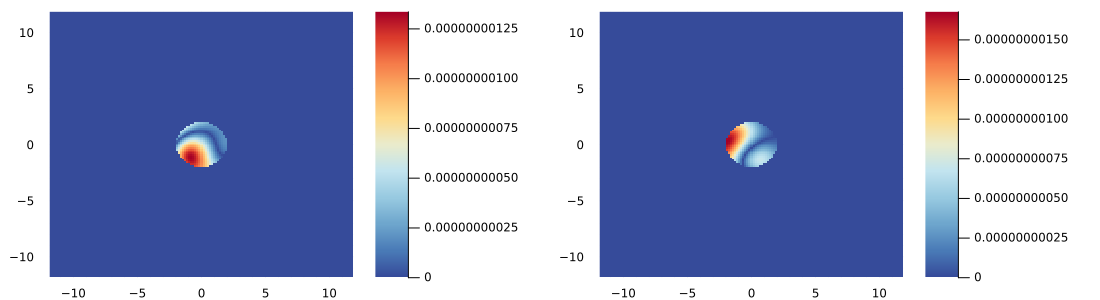

In [12]:
theme(:vibrant)
plot(heatmap(x_array,y_array,lq_res[4]),heatmap(x_array,y_array,lq_res[5]),size=(1100,300),right_margin=2Plots.cm)

In [13]:
print("real: ", lq_res[1],
    "\nimag: ", lq_res[2],
    "\nrcentre = ", lq_res[3])

real: 1.3359511275012892e-9
imag: 1.677024377005898e-9
rcentre = 1.3359511275012892e-9

#### Loop over velocities and take the largest value

In [14]:
### run on a bunch of threads in terminal
vels = 0:0.025:0.95
max_error_real = zeros(length(vels))
max_error_imag = zeros(length(vels))
max_error_rcentre = zeros(length(vels))

for i in 1:length(vels)
    v=vels[i]
    l_inner_x = 3pi/2
    l_inner_y = 3pi/2
    A = sub_ellipse(v,l_inner_x,l_inner_y,5*l_inner_x,5*l_inner_y,150,true)
    lq_res = lq(A,v)
    
    # store the maximum value
    max_error_real[i] = lq_res[1]
    max_error_imag[i] = lq_res[2]
    max_error_rcentre[i] = lq_res[3]
    print(v,"\t")

end

0.0	0.025	0.05	0.075	0.1	0.125	0.15	0.175	0.2	0.225	0.25	0.275	0.3	0.325	0.35	0.375	0.4	0.425	0.45	0.475	0.5	0.525	0.55	0.575	0.6	0.625	0.65	0.675	0.7	0.725	0.75	0.775	0.8	0.825	0.85	0.875	0.9	0.925	0.95	

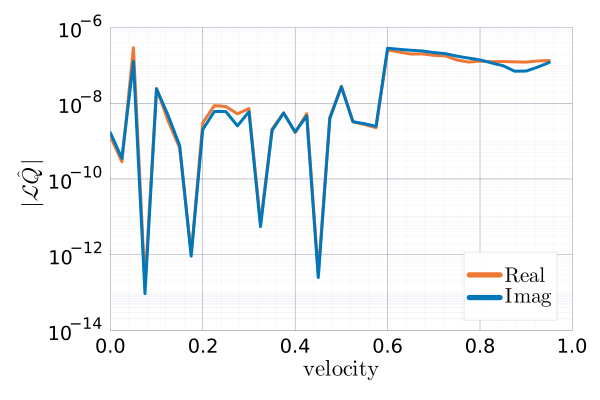

In [32]:
plt = plot(vels,max_error_real,label=L"\mathrm{Real}",
        xlabel=L"\mathrm{velocity}", ylabel=L"\mathcal{|L}\hat{Q}\,\,|",
        labelfontsize=15,tickfontsize=13,legendfontsize=14,
        linewidth=3,margin=0.5Plots.cm,yscale=:log10,ylims=[1e-14,1e-6])
plot!(plt,vels,max_error_imag,label=L"\mathrm{Imag}",
        xlims=[0,1],linewidth=3,gridalpha=0.5,legend=:bottomright)

In [22]:
norm(max_error_real,Inf)

2.9179407016327596e-7

### This data is saved with JLD2

In [39]:
using JLD2
using Plots
A = jldopen("data/LQ_check_data_2707.jld2")

JLDFile /Users/daire/shape-considerations-in-wdp/subcritical_elliptical/data/LQ_check_data_2707.jld2 (read-only)
 ├─🔢 info
 ├─🔢 vels
 ├─🔢 max_error_real
 └─🔢 max_error_imag

In [40]:
vels = A["vels"];
max_error_real = A["max_error_real"];
max_error_imag = A["max_error_imag"];

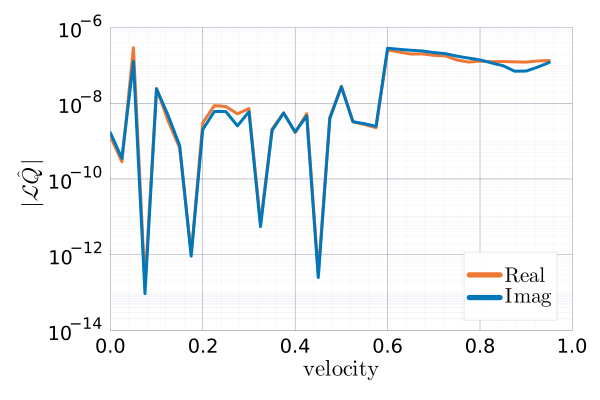

In [42]:
plt = plot(vels,max_error_real,label=L"\mathrm{Real}",
        xlabel=L"\mathrm{velocity}", ylabel=L"\mathcal{|L}\hat{Q}\,\,|",
        labelfontsize=15,tickfontsize=13,legendfontsize=14,
        linewidth=3,margin=0.5Plots.cm,yscale=:log10,ylims=[1e-14,1e-6])
plot!(plt,vels,max_error_imag,label=L"\mathrm{Imag}",
        xlims=[0,1],linewidth=3,gridalpha=0.5,legend=:bottomright)

----

$r=\pi/2$ results

In [1]:
using JLD2
using Plots
using LaTeXStrings
A = jldopen("data/sub_pi_lq_1408.jld2")

JLDFile /home/daire/shape-in-wdp/subcritical_elliptical/data/sub_pi_lq_1408.jld2 (read-only)
 ├─🔢 vels
 ├─🔢 max_error_real
 ├─🔢 max_error_imag
 └─🔢 max_error_rcentre

In [15]:
vels = A["vels"];
max_error_real = A["max_error_real"];
max_error_imag = A["max_error_imag"];
max_error_rcentre = A["max_error_rcentre"];

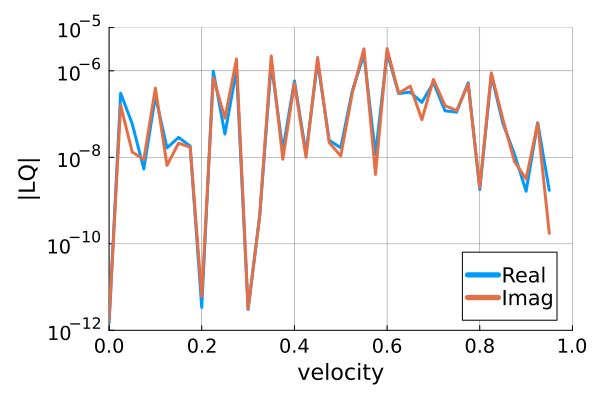

In [14]:
plt = plot(vels,max_error_real,label="Real",
        xlabel="velocity", ylabel="|LQ|",
        labelfontsize=15,tickfontsize=13,legendfontsize=14,
        linewidth=3,margin=0.5Plots.cm,yscale=:log10,ylims=[1e-12,1e-5],
        yticks=[1e-12,1e-10,1e-8,1e-6,1e-5])
plot!(plt,vels,max_error_imag,label="Imag",
        xlims=[0,1],linewidth=3,gridalpha=0.5,legend=:bottomright)